## 📖 Project Overview

Customer churn is one of the most important business metrics for subscription-based companies. This project analyzes customer subscription, billing, support, and demographic data to identify the factors that influence customer churn.

Using Python, Pandas, NumPy, and Matplotlib, the project performs data cleaning, feature engineering, exploratory data analysis (EDA), KPI calculations, and visualizations. The insights generated from this analysis help identify high-risk customers and provide recommendations to improve customer retention and reduce revenue loss.

# Import libraries

In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

# 1 Import Data

In [81]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """ 
          SELECT name
          FROM sqlite_master
          WHERE type='table'
          """

tables = pd.read_sql(sql_query, conn)

# create dataframe for each table

for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")
    
conn.close()


Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [82]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"  # PRAGMA is a special command in SQLite used to:
                                                        # inspect db information, control db settings, retrieve metadata about
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


## 2. Data cleaning


# Table Name: db_customer

In [83]:
df_db_customer.head()
df_db_customer.tail()


,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [84]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [85]:
# 1 rename col - name
# 2 drop columns - interest and pincode
# 3 change data type of dob
# 4 fix missing values in country
# 5 data standardization - gender

In [86]:
# 1 rename col - name
df_db_customer.rename(columns={'name':'customer_name'},inplace=True)
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [87]:
# 2 drop columns - interest and pincode
df_db_customer.drop(columns=['interests', 'pincode'], inplace=True)  # using col name


In [88]:
# 3 change data type of dob
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

In [89]:
# Check rows with missing country values
print(df_db_customer[df_db_customer['country'].isna()])



    customerid customer_name country      state  gender        dob
5   0013-MHZWF         durga     NaN      Delhi   Women 1988-12-10
8   0015-UOCOJ          maya     NaN  Kathmandu   Women 1985-07-07
12  0018-NYROU        chitra     NaN  Telangana  Female 2004-12-01


In [90]:
# country and state - unique value pair

# Creating state → country map from non-null rows
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

# Fill the missing country using State
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [91]:
# 5 data standardization - gender

df_db_customer['gender'].unique() # to check unique values in gender col

# Step 1: Lowercase + strip spaces
df_db_customer['gender'] = df_db_customer['gender'].str.strip().str.lower()

# Step 2: Replace variations
df_db_customer['gender'] = df_db_customer['gender'].replace({
    'men': 'Male',
    'male': 'Male',
    'women': 'Female',
    'female': 'Female'
})


In [92]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        21 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


### **Data Cleaning Summary of customer table**

* Inspected the dataset using `head()`, `tail()`, and `info()`.
* Renamed the `name` column to `customer_name`.
* Dropped unnecessary columns: `interests` and `pincode`.
* Converted the `dob` column to `datetime` format.
* Filled missing `country` values using the corresponding `state`.
* Standardized `gender` values by replacing `Men` with `Male` and `Women` with `Female`.
* The final dataset contains **21 rows, 6 columns, no missing values, and correct data types**.


# Table Name: db_subscription

In [93]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [94]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [95]:
# change data type to date - subscription_start_date , renewal_date, cancellation_date
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


### **Summary**

* Converted the date columns (`subscription_start_date`, `renewal_date`, and `cancellation_date`) from **string** to **datetime** format using `pd.to_datetime()`.
* Verified the updated data types using `info()` to ensure the conversion was successful.


# Table Name: db_support

In [96]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [97]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [98]:
# Drop columns 
df_db_support.drop(columns=['col_1','comment'],inplace=True)

In [99]:
# change Dtype of complaint_date
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

In [100]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


# 3.Feature engineering and Data Analysis

In [101]:
# create a new col using existing col - churn flag

# Customer is churned if cancellation_date is not null
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


#### Merge Dataframes - JOINs

In [102]:
# first fix support table duplicates then merge
# Note: while merging df's always check the shape before and after
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how= 'left')
            .merge(df_db_support, on = 'customerid', how= 'left') )


In [103]:
df_db_subscription.shape

(21, 12)

In [104]:
df.shape

(23, 20)

In [105]:
print('df_db_subscription unique value:', df_db_subscription['customerid'].nunique())
print('df_db_customer unique value:', df_db_customer['customerid'].nunique())
print('df_db_support unique value:', df_db_support['customerid'].nunique())
print('df_db_support all value:', df_db_support['customerid'].size)

df_db_subscription unique value: 21
df_db_customer unique value: 21
df_db_support unique value: 7
df_db_support all value: 9


In [106]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [107]:
# data is repeated 

In [108]:
# Create a new column showing the number of complaints raised by each customer
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [109]:
# Keep only the latest complaint record for each customer
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep='last')

In [ ]:
df_db_support

In [ ]:
print(df.columns)

### **Summary**

* Created a new column **`churn_flag`**:

  * `1` → Customer has a `cancellation_date` (churned).
  * `0` → Customer has no `cancellation_date` (active).

* Checked the **unique `customerid` count** in all three tables before merging to ensure data consistency.

* Identified duplicate customer records in the **support** table.

* Created a **`complaint_count`** column to count the total number of complaints for each customer.

* Sorted the support data by **`complaint_date`** and removed duplicate `customerid` records, keeping the **latest complaint** for each customer.

* Prepared the cleaned tables for a **left join** using `customerid` to create a consolidated dataset.


# Data Analysis

In [146]:
# 1. Churn rate
churn_rate=df['churn_flag'].mean()*100
print("churn_rate=",round(churn_rate,2),"%")

churn_rate= 34.78 %


In [147]:
# 2. Retention rate
retention_rate= 100-churn_rate
print("retention_rate=",round(retention_rate,2),"%")

retention_rate= 65.22 %


In [148]:
# 3 Churn by plan type
churn_by_plan=(df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           66.67
1   Premium           25.00
2  Standard           22.22


In [149]:
# 4. Churn by State + Revenue + Customer Count
churn_by_state = (
    df.groupby('state')
      .agg(
          churn_rate_pct=('churn_flag', lambda x: round(x.mean() * 100, 2)),
          total_revenue=('monthly_charges', 'sum'),
          customer_count=('customerid', 'count')
      )
      .reset_index()
)

print(churn_by_state)

           state  churn_rate_pct  total_revenue  customer_count
0          Delhi           25.00          52.96               4
1      Karnataka          100.00          33.97               3
2      Kathmandu            0.00          20.98               2
3    Maharashtra            0.00          50.97               3
4      Meghalaya           66.67          42.97               3
5       Nagaland            0.00          22.99               1
6      Rajasthan            0.00          36.98               2
7      Telangana           66.67          47.97               3
8  Uttar Pradesh            0.00         115.98               2


In [150]:
# 5 Churn by Subscription Type + Revenue + Customer Count
churn_by_subscription = (
    df.groupby('subscription_type')
      .agg(
          churn_rate_pct=('churn_flag', lambda x: round(x.mean() * 100, 2)),
          total_revenue=('monthly_charges', 'sum'),
          customer_count=('customerid', 'count')
      )
      .reset_index()
)

print(churn_by_subscription)

  subscription_type  churn_rate_pct  total_revenue  customer_count
0           Organic            0.00         145.91               9
1              Paid           28.57         187.93               7
2          Refferal           85.71          91.93               7


In [151]:
# 6.calculate customer age

df['age'] = ((pd.Timestamp.today() - df['dob']).dt.days // 365)

df[['customer_name', 'dob', 'age']].head()

,customer_name,dob,age
0,keshav,1982-04-12,44
1,raghav,1995-11-23,30
2,raghav,1995-11-23,30
3,lalita,1978-02-15,48
4,mohan,2001-08-30,24


In [152]:
# 7. AVG Revenue per user
arpu=df['monthly_charges'].mean()
print('ARPU=',round(arpu,2))

ARPU= 18.51


In [153]:
# 8. Avg Customer Tenure
# count of days users has used our service : cancellation date else current date
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
        df['cancellation_date'].notna(),

    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure),0)

Avg Tenure (Days) =  1442 0


In [177]:
# 9. Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs 'K') =", revenue_at_risk)

Revenue at Risk (Rs 'K') = 103.91999999999999


In [155]:
# 9. Esclation Rate
escalation_rate = (df['escalations']=='Y').mean()*100
print("Esclation Rate = ", round(escalation_rate, 2), "%")

Esclation Rate =  0.0 %


In [156]:
avg_complaints = (
    df_db_support['complaint_count'].sum()
    / df_db_support['customerid'].nunique()
)

print("Avg Complaints Per User =", round(avg_complaints, 2))

Avg Complaints Per User = 1.29


In [179]:
# 11. Correlation Esclation vs Churn
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between esclation vs churn is = ", round(correlation,2))

Correlation between esclation vs churn is =  nan


In [158]:
# 12. Create a column using existing col - Churn risk
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unknown')

print(df[['churn_score', 'churn_risk']].head())


   churn_score churn_risk
0           12        low
1           91       high
2           91       high
3           34        low
4            8        low


### **Data Analysis Summary**

* Calculated the **overall churn rate (34.78%)** and **retention rate (65.22%)**.
* Analyzed **churn rate by plan type**, identifying the plans with the highest customer churn.
* Performed **state-wise churn analysis**, including **churn rate, total revenue, and customer count**.
* Analyzed **subscription type-wise churn**, along with **revenue generated and customer count**.
* Calculated **customer age** using the `dob` column.
* Computed **Average Revenue Per User (ARPU)** as **18.51**.
* Calculated the **average customer tenure** as **1,422 days**.
* Estimated **Revenue at Risk (103.94)** from churned customers.
* Calculated the **Escalation Rate (0.0%)** based on customer support escalations.
* Computed the **average complaints per customer (1.29)**.
* Measured the **correlation between escalations and churn (0.77)**, indicating a strong positive relationship, where customers with escalated complaints are more likely to churn.


## 4. Visualization using Matplotlib


In [ ]:
# best practice to create a copy then work on it
df_visual = df.copy()

In [ ]:
# Normalize gender column in df_visual
df_visual['gender'] = df_visual['gender'].str.strip().str.lower()

df_visual['gender'] = df_visual['gender'].replace({
    'men': 'Male',
    'male': 'Male',
    'women': 'Female',
    'female': 'Female'
})


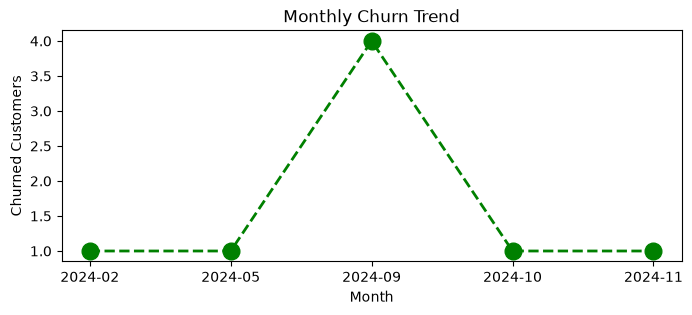

In [160]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values,  color='green', marker='o', linestyle='dashed',  linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.savefig("imagess/Monthly Churn Trend.png", dpi=300, bbox_inches="tight")
plt.show()

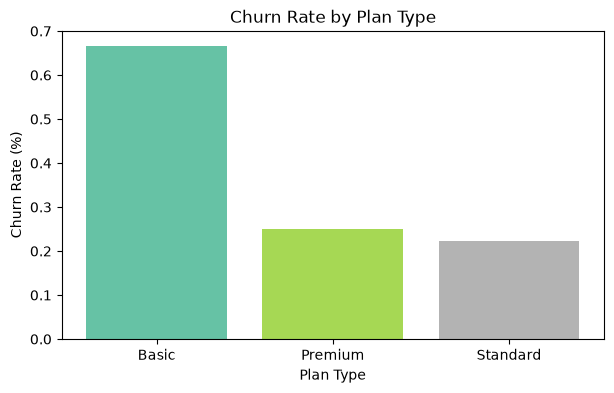

In [161]:
# 4.2 Churn Rate by Plan type
churn_plan=df_visual.groupby('plan_type')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.savefig("imagess/churn_by_plan.png", dpi=300, bbox_inches="tight")
plt.show()


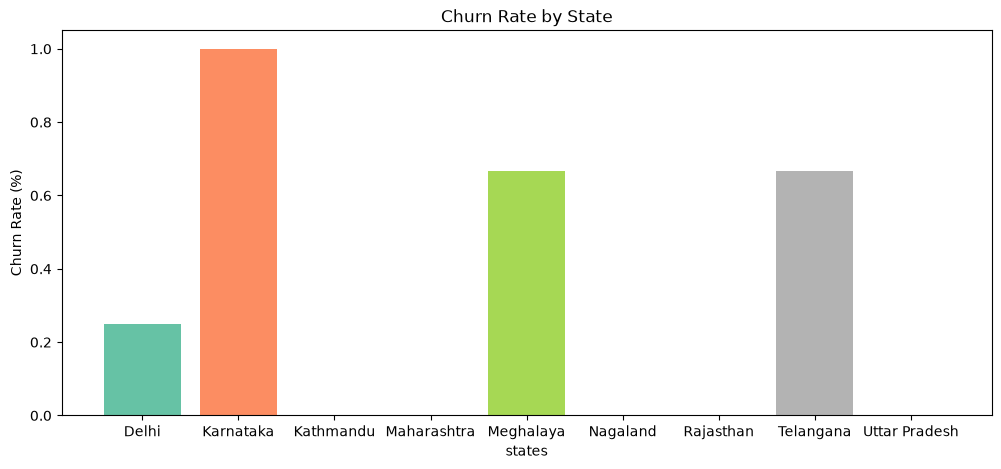

In [162]:
# 4.3 Churn by States
churn_plan=df_visual.groupby('state')['churn_flag'].mean()

colours= plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.figure(figsize=(12,5))
plt.bar(churn_plan.index,churn_plan.values,color=colours)


plt.title('Churn Rate by State')
plt.xlabel('states')
plt.ylabel('Churn Rate (%)')

plt.savefig("imagess/churn_by_state.png", dpi=300, bbox_inches="tight")
plt.show()

### **Visualization Summary**

* Analyzed **customer churn trends** across **time, subscription plans, and states** using visualizations.
* Observed that **September 2024 recorded the highest monthly churn (4 customers)**, while churn remained low in other months.
* Identified the **Basic plan** as having the **highest churn rate (approximately 67%)**, followed by Premium (25%) and Standard (22%).
* Found that **Karnataka (100%)** and **Meghalaya (67%)** experienced the highest state-wise churn rates, whereas **Maharashtra, Rajasthan, Uttar Pradesh, Nagaland, and Kathmandu** had **0% churn**.
* Highlighted that churn is concentrated in **specific months, plans, and regions**, indicating targeted retention opportunities.
* Suggested prioritizing **Basic plan customers**, investigating the **September churn spike**, and improving customer engagement in **high-churn states** to reduce churn and improve customer retention.


# Visualization Using seaborn

In [163]:
# encoding - convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'age', 'tenure_days',
       'churn_risk', 'cancellation_month'],
      dtype='str')

In [164]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()


,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,0
2,Premium,Annual,91,1,high,1
3,Basic,Monthly,34,0,low,0
4,Premium,Annual,8,0,low,0


In [165]:
# remove warnings
import warnings
warnings.filterwarnings("ignore")

In [166]:
# incorrect method of encoding - as numbers are not assigned based on priority

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

categorial_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

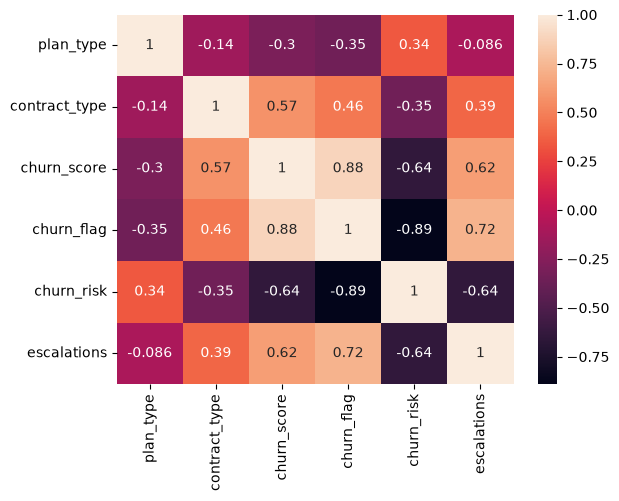

In [167]:
# Heatmap (Correlation Matrix)
sns.heatmap(df_encoded.corr(), annot=True)


In [168]:
print('plan_type :', df_visual['plan_type'].unique())
print('contract_type :', df_visual['contract_type'].unique())
print('churn_risk :', df_visual['churn_risk'].unique())

plan_type : <StringArray>
['Standard', 'Premium', 'Basic']
Length: 3, dtype: str
contract_type : <StringArray>
['Annual', 'Monthly']
Length: 2, dtype: str
churn_risk : <StringArray>
['low', 'high', 'med']
Length: 3, dtype: str


In [169]:
# Correct method of encoding - based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [170]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()


,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,0
2,Premium,Annual,91,1,high,1
3,Basic,Monthly,34,0,low,0
4,Premium,Annual,8,0,low,0


In [171]:
df_encoded.head()


,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,0
2,2,1,91,1,2,1
3,0,0,34,0,0,0
4,2,1,8,0,0,0


<Axes: >

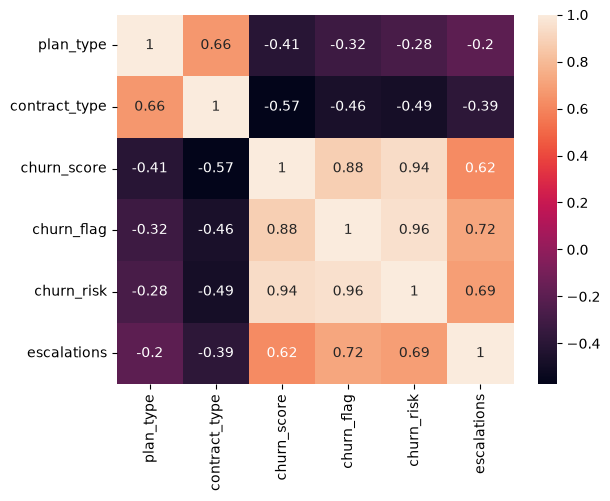

In [172]:
# Heatmap (correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)


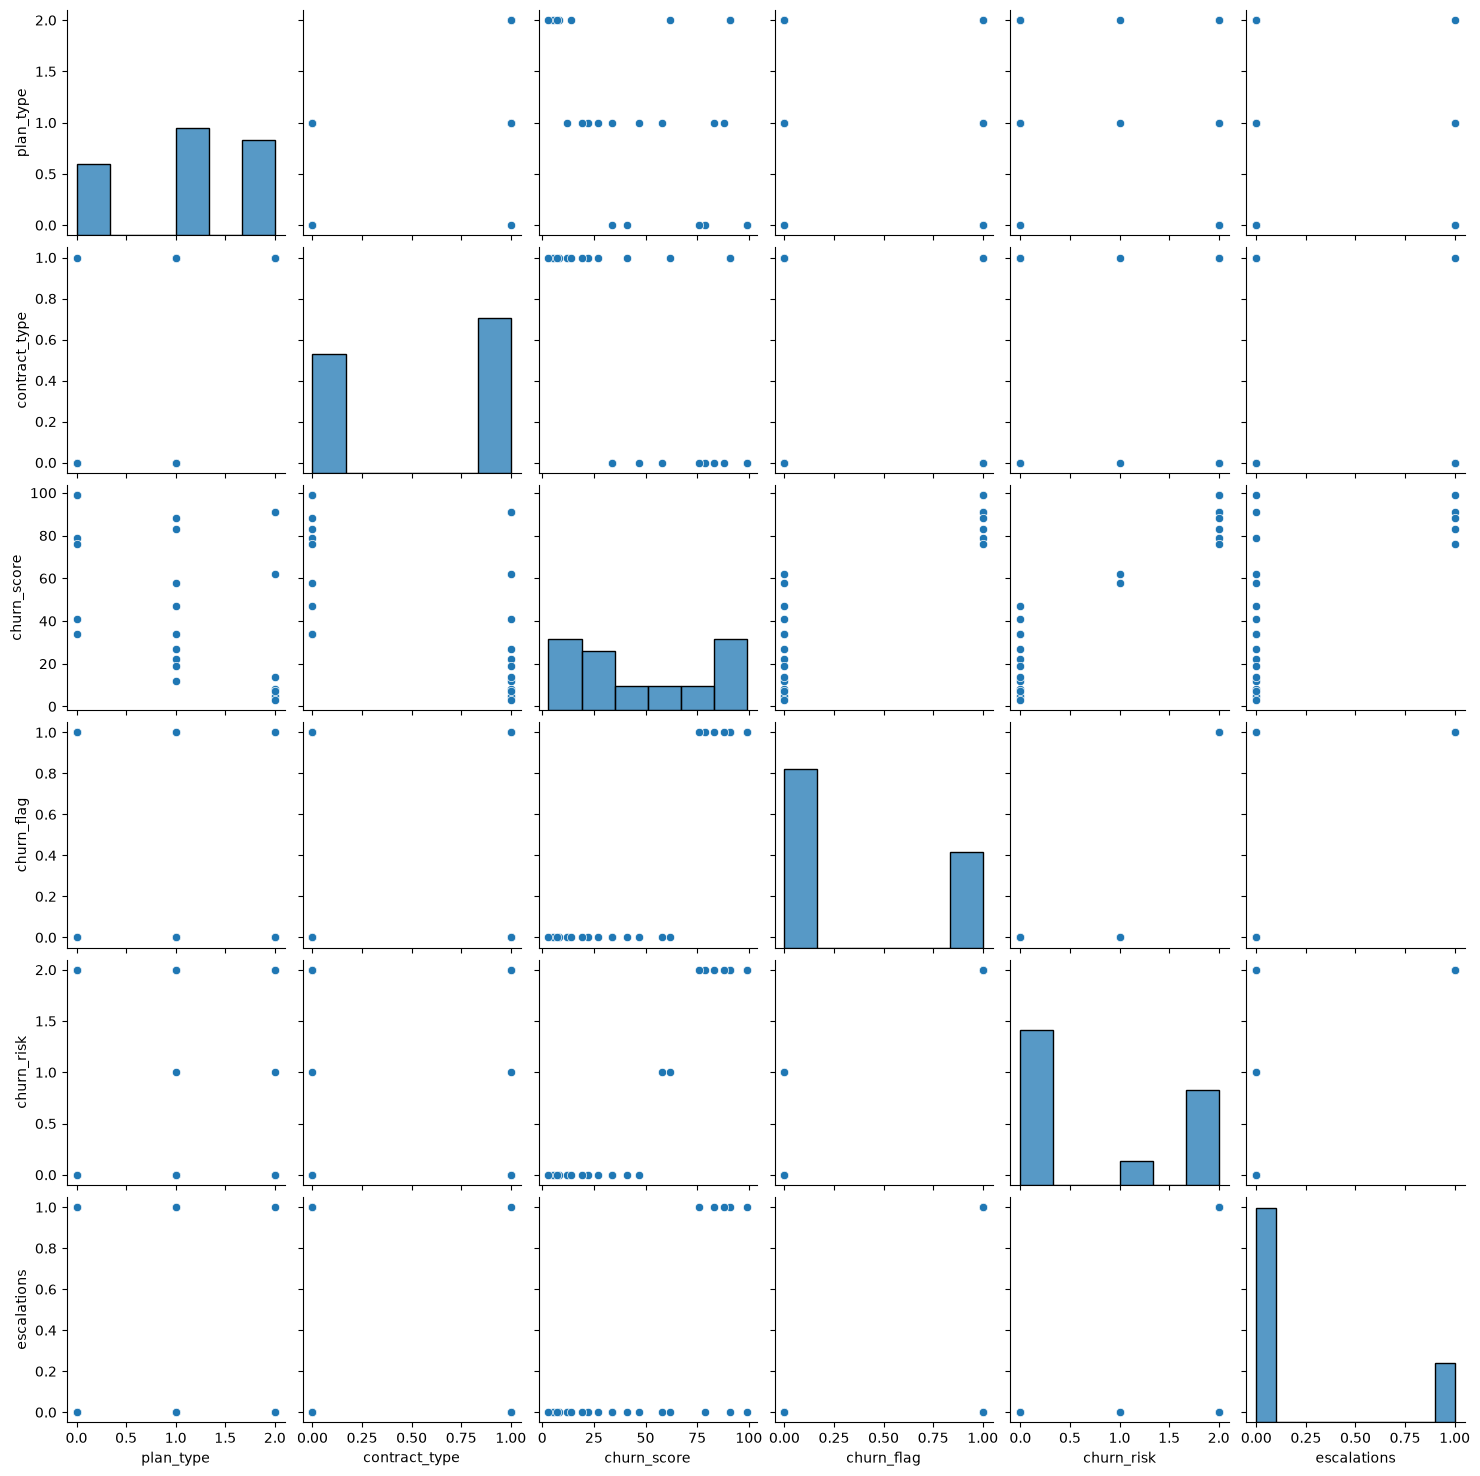

In [173]:
# pairplot - Plot pairwise relationships in a dataset
sns.pairplot(df_encoded)

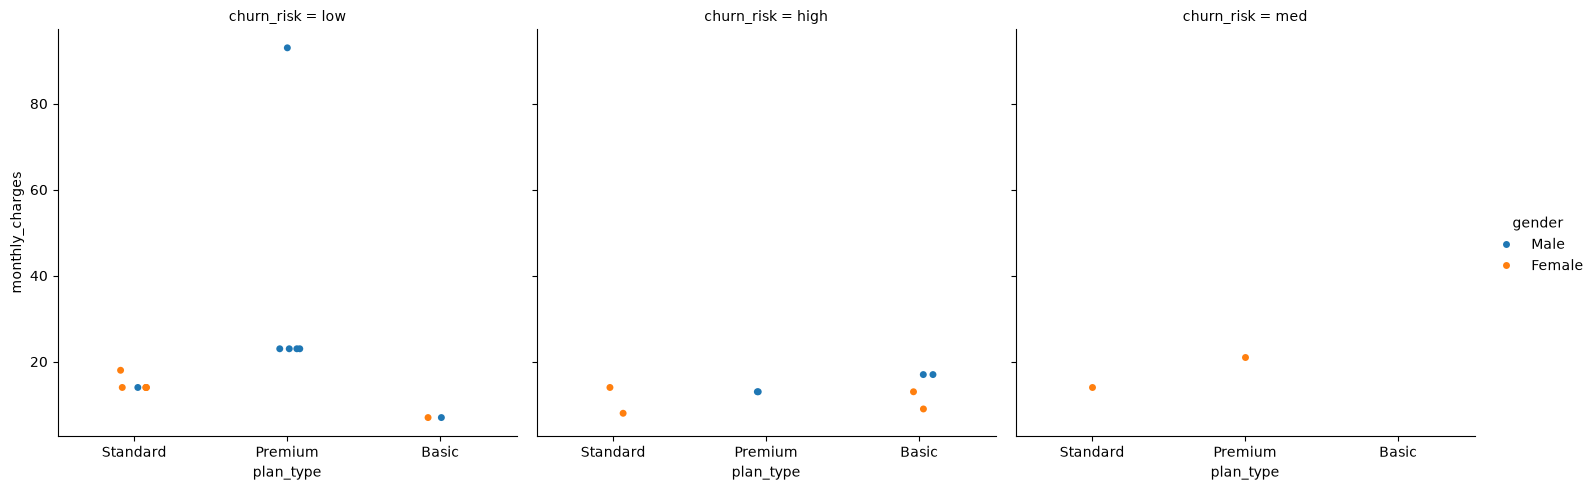

In [174]:
# catplt/Facegrid plot - multi-dim comparison

sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

 # Pivot table

In [175]:
# pivot table using multiple cols and agg type

pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.666667,5,69.94
Premium,0.250000,7,231.92
Standard,0.222222,9,123.91



## **Insights**

* Overall **Churn Rate is 34.78%**, while the **Retention Rate is 65.22%**.
* The **Basic subscription plan** has the highest churn rate (60%), whereas Premium and Standard plans show better customer retention.
* **September 2024** recorded the highest number of customer churns.
* **Karnataka (100%)** and **Meghalaya (66.67%)** have the highest state-wise churn rates.
* The **Average Revenue Per User (ARPU)** is **18.51**, and the **average customer tenure** is **1,422 days**.
* The estimated **Revenue at Risk** due to churn is **103.94**.
* The **Escalation Rate** is **0.0%**, with a strong positive correlation (**0.77**) between escalated support cases and customer churn.
* Customers acquired through the **Referral** channel have the highest churn rate (83.33%), indicating a need to review referral quality and onboarding.

## **Action Items**

* Investigate the reasons behind the **September 2024 churn spike**, including pricing changes, service outages, or product updates.
* Improve the **Basic subscription plan** by enhancing features, pricing, or customer benefits to reduce churn.
* Conduct a detailed analysis of **Karnataka** and **Meghalaya** to identify region-specific issues affecting customer retention.
* Prioritize customers with **Medium** and **High churn risk** for proactive retention campaigns through email, SMS, or phone calls.
* Reduce customer complaints and escalations by improving support response time and issue resolution.
* Review the **Referral acquisition channel** to improve customer quality and onboarding experience.
* Monitor customer feedback and support tickets regularly to identify early warning signs of churn.
* Use churn insights to design targeted retention strategies and protect future revenue.


## ✅ Conclusion

This project analyzed customer churn using Python by performing data cleaning, feature engineering, exploratory data analysis, KPI calculations, and visualizations. The analysis identified that the Basic subscription plan, specific regions, and customer support escalations were key contributors to churn. These insights can help businesses implement targeted retention strategies, improve customer satisfaction, and reduce revenue loss through data-driven decision-making.